Overall population over ticks:

Total Runs Found in DB: 2
Analysing Run ID: 1
Total ticks recorded in this run: 334
The population at the end of Run 1 was 1379


,id,run_id,tick_number,timestamp,population
0,1,1,1,2026-04-07T22:45:42.392149,200
1,2,1,2,2026-04-07T22:45:42.659550,200
2,3,1,3,2026-04-07T22:45:42.934007,200
3,4,1,4,2026-04-07T22:45:43.212326,200
4,5,1,5,2026-04-07T22:45:43.484634,200


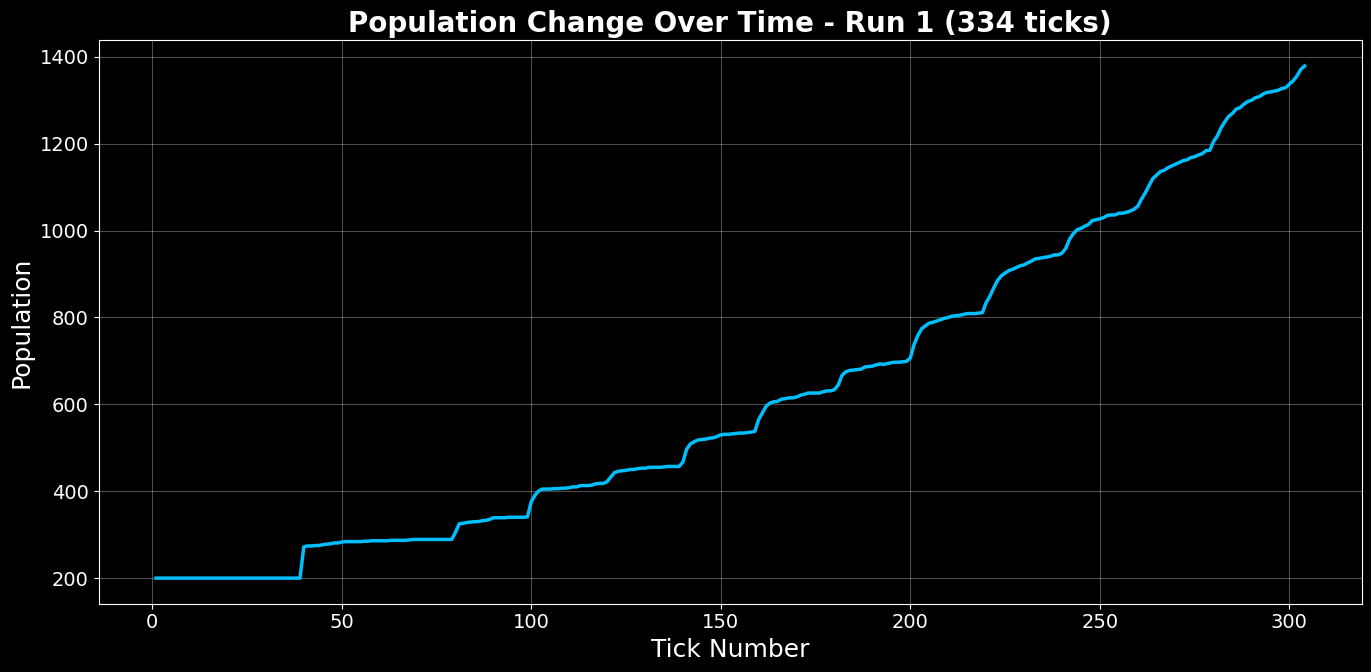

Male/female population columns not found in ticks table. Skipping gender split plot.

--- Population Statistics for Run 1 ---
Total Ticks Plotted: 334
Starting Population: 200
Ending Population: 1379
Maximum Population: 1379
Minimum Population: 200
Average Population: 622.53
Population Change: 1179


In [ ]:
# --- CONFIGURATION ---
target_run_id = 1
# ---------------------

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Set up dark theme
plt.style.use('dark_background')
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'legend.fontsize': 16,
})

# Connect to the database
conn = sqlite3.connect("data/ecosystem.db")

# 1. Verify Run exists
runs_df = pd.read_sql_query("SELECT * FROM runs", conn)

if target_run_id in runs_df['id'].values:
    print(f"Analyzing Species Population for Run ID: {target_run_id}")

    # 2. SQL Query to join Ticks with Creature States and count by Species
    # We count how many of each species exist for every tick in the target run
    query = f"""
    SELECT 
        t.tick_number, 
        cs.species, 
        COUNT(cs.creature_id) as species_count
    FROM ticks t
    JOIN creature_states cs ON t.id = cs.tick_id
    WHERE t.run_id = {target_run_id}
    GROUP BY t.tick_number, cs.species
    ORDER BY t.tick_number
    """
    
    species_df = pd.read_sql_query(query, conn)

    if not species_df.empty:
        # 3. Pivot the data so we have columns for 'erf' and 'Glooper'
        # This makes it much easier to plot
        pivot_df = species_df.pivot(index='tick_number', columns='species', values='species_count').fillna(0)
        
        # Ensure columns exist even if one species went extinct immediately
        if 'erf' not in pivot_df.columns: pivot_df['erf'] = 0
        if 'Glooper' not in pivot_df.columns: pivot_df['Glooper'] = 0

        print(f"Data loaded. Ticks recorded: {len(pivot_df)}")
        display(pivot_df.head())

        # 4. Create the Predator-Prey Graph
        plt.figure(figsize=(15, 8))
        
        # Plot Erfs (Prey)
        plt.plot(pivot_df.index, pivot_df['erf'], label='Erfs (Prey)', color='#00FF7F', linewidth=3)
        
        # Plot Gloopers (Predators)
        plt.plot(pivot_df.index, pivot_df['Glooper'], label='Gloopers (Predators)', color='#FF4500', linewidth=3)

        plt.xlabel('Tick Number')
        plt.ylabel('Population Count')
        plt.title(f'Species Population Dynamics - Run {target_run_id}')
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

        # 5. Summary Statistics
        print(f"\n--- Species Statistics for Run {target_run_id} ---")
        for species in pivot_df.columns:
            print(f"\n[{species.upper()}]")
            print(f"  Max Population: {int(pivot_df[species].max())}")
            print(f"  Final Population: {int(pivot_df[species].iloc[-1])}")
            if pivot_df[species].iloc[-1] == 0:
                # Find the tick where they went extinct
                extinct_tick = pivot_df[pivot_df[species] > 0].index.max()
                print(f"  STATUS: EXTINCT at tick {extinct_tick}")
            else:
                print(f"  STATUS: SURVIVED")

    else:
        print(f"No creature state data found for Run ID: {target_run_id}")
else:
    print(f"Error: Run ID {target_run_id} not found.")

conn.close()

male/female population over ticks:

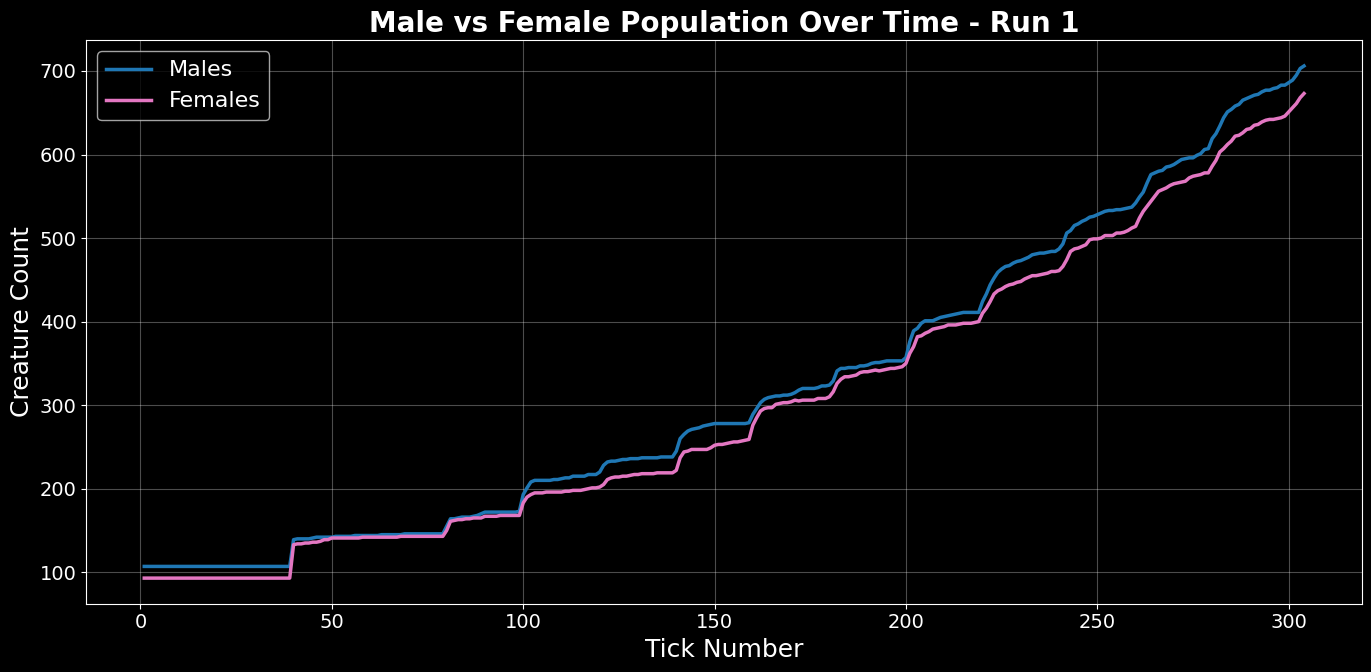

In [12]:
# Separate plot cell for male/female population over ticks
# The ticks table only stores total population, so we derive sex counts from creature_states.
# Some runs contain duplicated tick_number values after resuming, which can artificially inflate counts.

# Apply dark theme and larger fonts for poster visibility
plt.style.use('dark_background')
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 22
})

query = '''
SELECT t.tick_number,
       cs.sex,
       COUNT(*) AS count
FROM creature_states cs
JOIN (
    SELECT tick_number, MAX(id) AS id
    FROM ticks
    WHERE run_id = ?
    GROUP BY tick_number
) t ON cs.tick_id = t.id
GROUP BY t.tick_number, cs.sex
ORDER BY t.tick_number, cs.sex
'''
gender_df = pd.read_sql_query(query, conn, params=(target_run_id,))

if gender_df.empty:
    print('No creature sex data found for this run. The ticks table only stores total population.')
else:
    pivot_df = gender_df.pivot(index='tick_number', columns='sex', values='count').fillna(0)
    pivot_df = pivot_df.rename(columns={
        'M': 'Males',
        'F': 'Females',
    })

    plt.figure(figsize=(max(14, len(pivot_df) / 50), 7))
    if 'Males' in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df['Males'], label='Males', color='#1f77b4', linewidth=2.5)
    if 'Females' in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df['Females'], label='Females', color='#e377c2', linewidth=2.5)

    plt.xlabel('Tick Number', fontsize=18)
    plt.ylabel('Creature Count', fontsize=18)
    plt.title(f'Male vs Female Population Over Time - Run {target_run_id}', fontsize=20, fontweight='bold')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Age distribution graph for males and females at the latest tick snapshot:

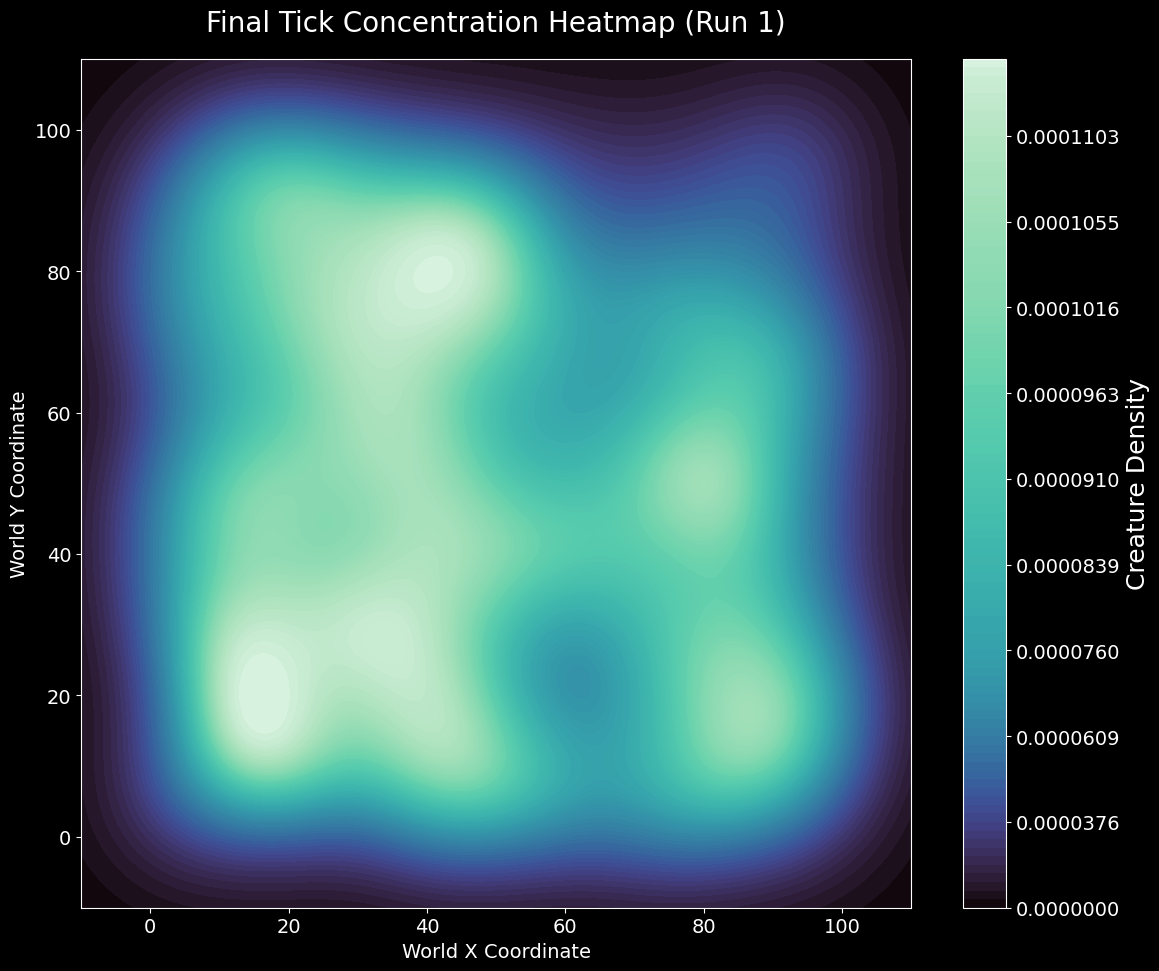

In [13]:
import seaborn as sns

# 1. Configuration
# target_run_id should be defined in your first cell
# conn should be your active sqlite3 connection

# 2. Optimized Query using your specific column names: pos_x, pos_y
query = '''
SELECT cs.pos_x, cs.pos_y 
FROM creature_states cs
JOIN ticks t ON cs.tick_id = t.id
WHERE t.run_id = ? 
  AND t.tick_number = (SELECT MAX(tick_number) FROM ticks WHERE run_id = ?)
  AND cs.alive = 1
'''

try:
    pos_df = pd.read_sql_query(query, conn, params=(target_run_id, target_run_id))

    if not pos_df.empty:
        # 3. Create the Density Plot
        plt.figure(figsize=(12, 10))
        
        # 'mako' or 'viridis' look great on dark backgrounds
        # fill=True creates the solid "heat" effect
        sns.kdeplot(
            data=pos_df, x='pos_x', y='pos_y', 
            fill=True, 
            thresh=0, 
            levels=100, 
            cmap='mako',
            cbar=True,
            cbar_kws={'label': 'Creature Density'}
        )

        # 4. Styling
        plt.title(f'Final Tick Concentration Heatmap (Run {target_run_id})', fontsize=20, pad=20)
        plt.xlabel('World X Coordinate', fontsize=14)
        plt.ylabel('World Y Coordinate', fontsize=14)
        
        # Adjust these limits based on your Godot world size
        plt.xlim(pos_df['pos_x'].min() - 10, pos_df['pos_y'].max() + 10) 
        plt.ylim(pos_df['pos_y'].min() - 10, pos_df['pos_y'].max() + 10)

        plt.tight_layout()
        plt.show()
    else:
        print(f"No living creatures found at the end of Run {target_run_id} to map.")

except Exception as e:
    print(f"Error generating heatmap: {e}")